In [ ]:
# 1: if we can define the period very distinctlyi then that is going to be seasonality.
# 2: if we have some sort of trends that dont really seem to have any sort of repetition sometimes they go up sometimes they go down.
#    Many real world dataset are going to have this sort of behavior. Those are known cycles or cyclical behavior where we have trends
#    with no set repetition over a particular period.


In [ ]:
# The Hodrick-Prescott filter seperates a time series y_t into a trend component T_t and a cyclical component c_t. 
# => y_t = T_t + c_t

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline

In [4]:
df = pd.read_csv("Data/macrodata.csv", index_col=0, parse_dates=True)

<pre><strong>US Macroeconomic Data for 1959Q1 - 2009Q3</strong>
Number of Observations - 203
Number of Variables - 14
Variable name definitions:
    year      - 1959q1 - 2009q3
    quarter   - 1-4
    realgdp   - Real gross domestic product (Bil. of chained 2005 US$,
                seasonally adjusted annual rate)
    realcons  - Real personal consumption expenditures (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realinv   - Real gross private domestic investment (Bil. of chained
                2005 US$, seasonally adjusted annual rate)
    realgovt  - Real federal consumption expenditures & gross investment
                (Bil. of chained 2005 US$, seasonally adjusted annual rate)
    realdpi   - Real private disposable income (Bil. of chained 2005
                US$, seasonally adjusted annual rate)
    cpi       - End of the quarter consumer price index for all urban
                consumers: all items (1982-84 = 100, seasonally adjusted).
    m1        - End of the quarter M1 nominal money stock (Seasonally
                adjusted)
    tbilrate  - Quarterly monthly average of the monthly 3-month
                treasury bill: secondary market rate
    unemp     - Seasonally adjusted unemployment rate (%)
    pop       - End of the quarter total population: all ages incl. armed
                forces over seas
    infl      - Inflation rate (ln(cpi_{t}/cpi_{t-1}) * 400)
    realint   - Real interest rate (tbilrate - infl)</pre>

In [5]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


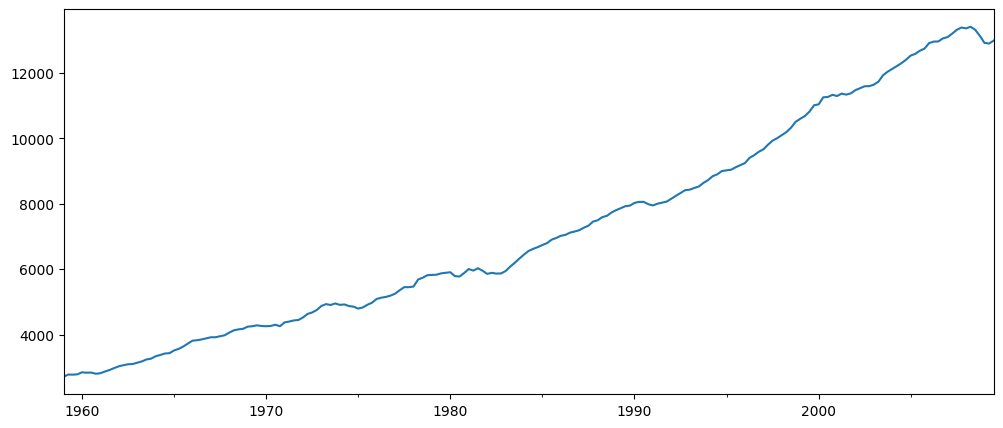

In [11]:
df["realgdp"].plot(figsize=(12, 5));

#### Introduction to Statmodels Library

In [10]:
# !pip install statsmodels
from statsmodels.tsa.filters.hp_filter import hpfilter

In [15]:
# The Hodrick-Prescott filter
# It has two parameters,
#  - one of them is X so called dataset,
#  - second one lambda refers what the actual frequency of your data is.
# And returns a tuple that includes cyclical component and trend component.

gdp_cycle, gdp_trend = hpfilter(df["realgdp"], lamb=1600)

In [16]:
type(gdp_cycle)

pandas.core.series.Series

In [17]:
type(gdp_trend)

pandas.core.series.Series

<Axes: >

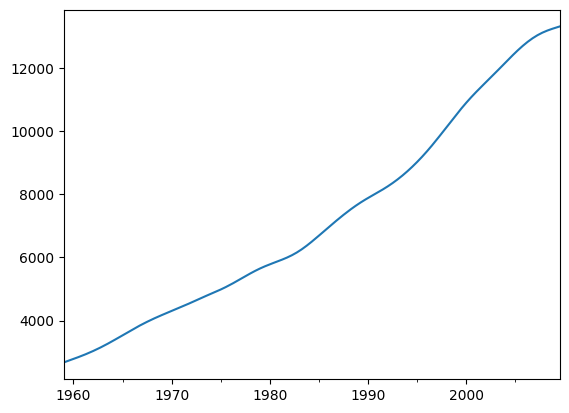

In [18]:
gdp_trend.plot()

In [19]:
df["trend"] = gdp_trend

In [20]:
df.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,trend
1959-03-31,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,2670.837085
1959-06-30,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,2698.712468
1959-09-30,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,2726.612545
1959-12-31,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,2754.612067
1960-03-31,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,2782.816333


<Axes: >

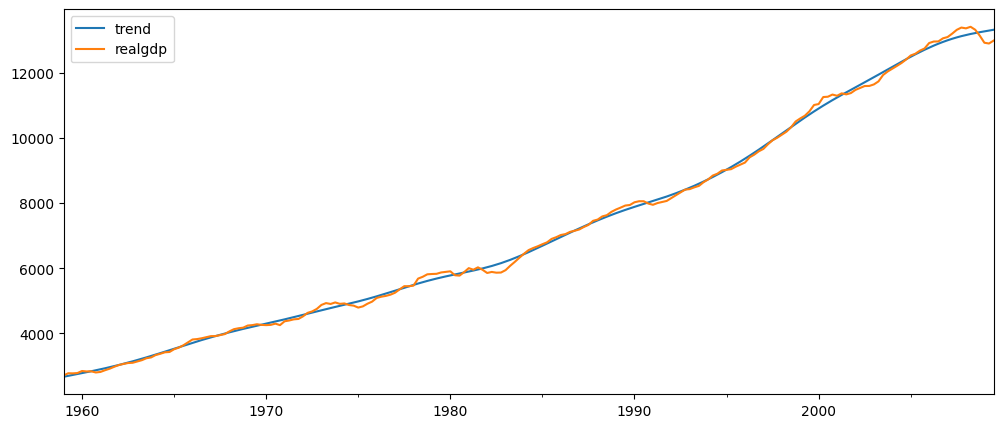

In [22]:
df[["trend", "realgdp"]].plot(figsize=(12, 5))

<Axes: >

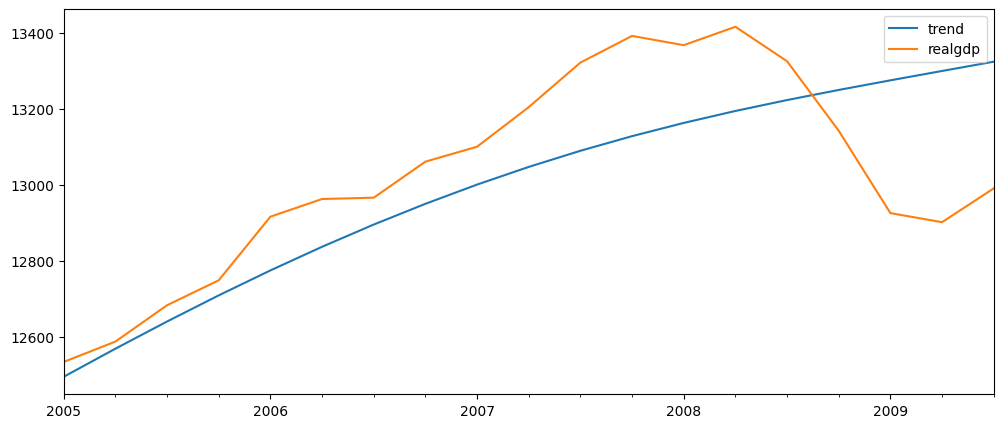

In [23]:
df[["trend", "realgdp"]]["2005-01-01":].plot(figsize=(12, 5))

### ETS

## Error/Trend/Seasonality Models
As we begin working with <em>endogenous</em> data ("endog" for short) and start to develop forecasting models, it helps to identify and isolate factors working within the system that influence behavior. Here the name "endogenous" considers internal factors, while "exogenous" would relate to external forces. These fall under the category of <em>state space models</em>, and include <em>decomposition</em> (described below), and <em>exponential smoothing</em> (described in an upcoming section).

The <a href='https://en.wikipedia.org/wiki/Decomposition_of_time_series'>decomposition</a> of a time series attempts to isolate individual components such as <em>error</em>, <em>trend</em>, and <em>seasonality</em> (ETS). We've already seen a simplistic example of this in the <strong>Introduction to Statsmodels</strong> section with the Hodrick-Prescott filter. There we separated data into a trendline and a cyclical feature that mapped observed data back to the trend.

<div class="alert alert-info"><h3>Related Function:</h3>
<tt><strong><a href='https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html'>statsmodels.tsa.seasonal.seasonal_decompose</a></strong><font color=black>(x, model)</font>&nbsp;&nbsp;
Seasonal decomposition using moving averages</tt>
<h3>For Further Reading:</h3>
<strong>
<a href='https://otexts.com/fpp2/ets.html'>Forecasting: Principles and Practice</a></strong>&nbsp;&nbsp;<font color=black>Innovations state space models for exponential smoothing</font><br>
<strong>
<a href='https://en.wikipedia.org/wiki/Decomposition_of_time_series'>Wikipedia</a></strong>&nbsp;&nbsp;<font color=black>Decomposition of time series</font></div>

## Seasonal Decomposition
Statsmodels provides a <em>seasonal decomposition</em> tool we can use to separate out the different components. This lets us see quickly and visually what each component contributes to the overall behavior.


We apply an <strong>additive</strong> model when it seems that the trend is more linear and the seasonality and trend components seem to be constant over time (e.g. every year we add 10,000 passengers).<br>
A <strong>multiplicative</strong> model is more appropriate when we are increasing (or decreasing) at a non-linear rate (e.g. each year we double the amount of passengers).

For these examples we'll use the International Airline Passengers dataset, which gives monthly totals in thousands from January 1949 to December 1960.

#### ETS Decomposition

In [13]:
# ETS Models
# ETS: Error - Trend - Seasonality

# When performing an ETS decomposition, there is two types of main ETS models.

# 1: Additive Model, trend is more linear and seasonality and trend components seems to be constant over time
# (e.g. every year we add 10.000 passengers)

# 2: Multiplicative Model is more appropriate when we are increasing or decreasing at a non-linear rate
# (e.g. each year we double the amount of passengers.)

In [14]:
import pandas as pd

df_airline = pd.read_csv("Data/airline_passengers.csv", index_col="Month", parse_dates=True)

df_airline

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [18]:
df_airline = df_airline.dropna()

df_airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


<Axes: xlabel='Month'>

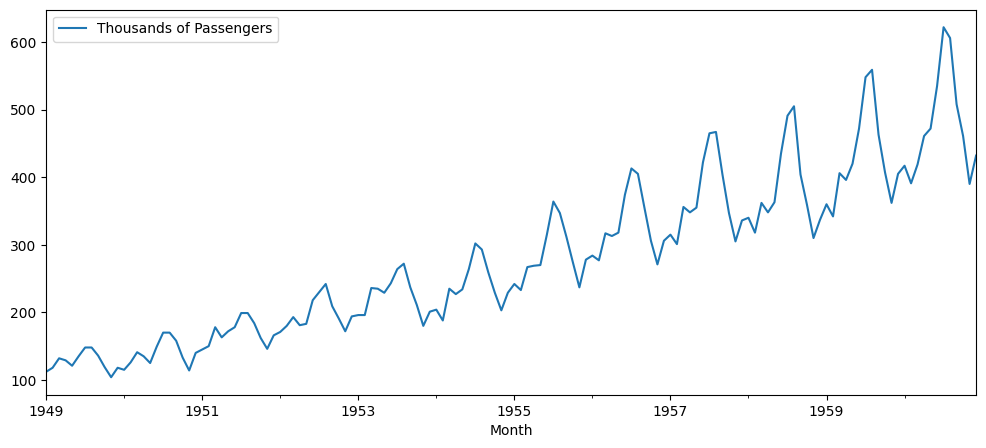

In [19]:
df_airline.plot(figsize=(12, 5))

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [26]:
result = seasonal_decompose(df_airline["Thousands of Passengers"], model="multiplicative")

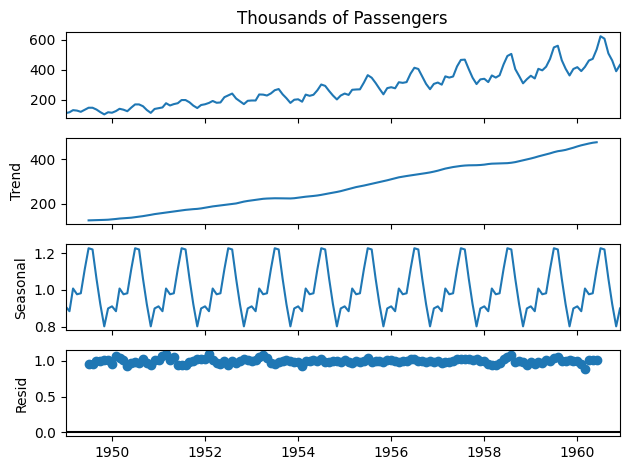

In [32]:
result.plot();

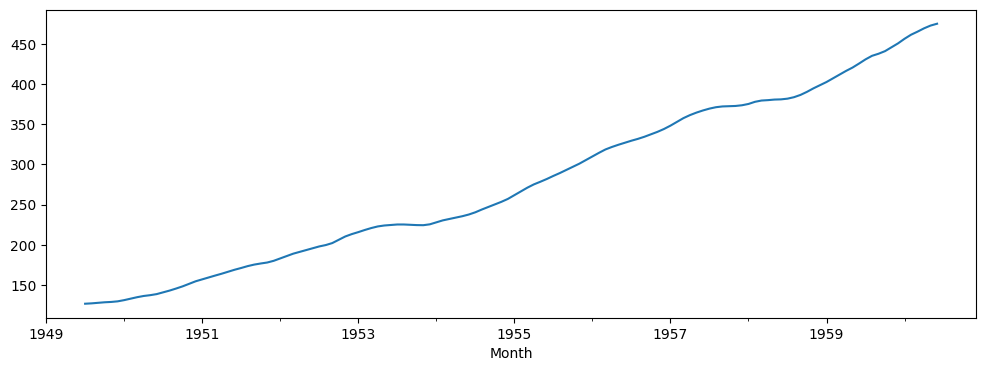

In [35]:
result.trend.plot(figsize=(12,4));

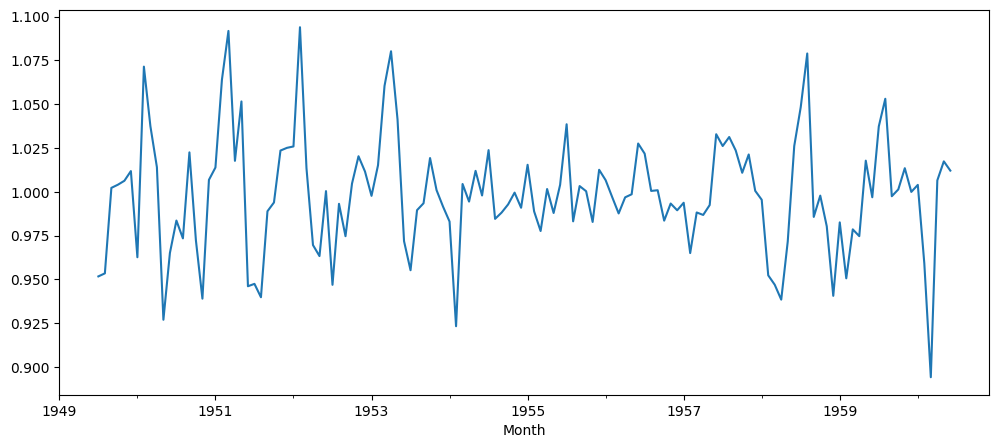

In [37]:
result.resid.plot(figsize=(12,5));

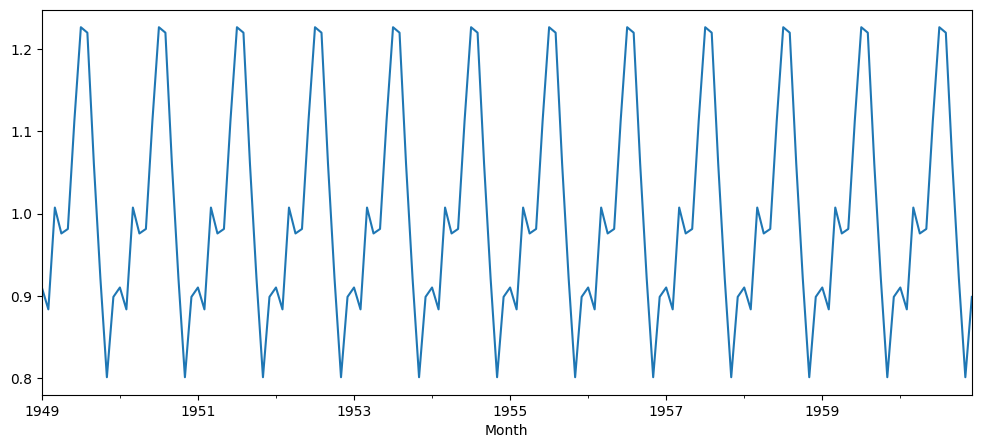

In [38]:
result.seasonal.plot(figsize=(12,5));

#### EWMA Model

#### Exponentially Weighted Moving Average 

We just showed how to calculate the SMA based on some window. However, basic SMA has some weaknesses:
* Smaller windows will lead to more noise, rather than signal
* It will always lag by the size of the window
* It will never reach to full peak or valley of the data due to the averaging.
* Does not really inform you about possible future behavior, all it really does is describe trends in your data.
* Extreme historical values can skew your SMA significantly

To help fix some of these issues, we can use an <a href='https://en.wikipedia.org/wiki/Exponential_smoothing'>EWMA (Exponentially weighted moving average)</a>.

EWMA will allow us to reduce the lag effect from SMA and it will put more weight on values that occured more recently (by applying more weight to the more recent values, thus the name). The amount of weight applied to the most recent values will depend on the actual parameters used in the EWMA and the number of periods given a window size.
[Full details on Mathematics behind this can be found here](http://pandas.pydata.org/pandas-docs/stable/user_guide/computation.html#exponentially-weighted-windows).
Here is the shorter version of the explanation behind EWMA.

The formula for EWMA is:
### $y_t =   \frac{\sum\limits_{i=0}^t w_i x_{t-i}}{\sum\limits_{i=0}^t w_i}$

In [39]:
# EWMA: Exponentially Weighted Moving Average
# SMA: Simple Moving Average

## EWMA attemts to overcome some weakness from basic SMA.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as ply
%matplotlib inline

In [46]:
airline = pd.read_csv("Data/airline_passengers.csv", index_col="Month")

airline.head()

,Thousands of Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


In [47]:
airline.index

Index(['1949-01', '1949-02', '1949-03', '1949-04', '1949-05', '1949-06',
       '1949-07', '1949-08', '1949-09', '1949-10',
       ...
       '1960-03', '1960-04', '1960-05', '1960-06', '1960-07', '1960-08',
       '1960-09', '1960-10', '1960-11', '1960-12'],
      dtype='object', name='Month', length=144)

In [48]:
airline.dropna()

,Thousands of Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121
...,...
1960-08,606
1960-09,508
1960-10,461


In [49]:
airline.index = pd.to_datetime(airline.index)

In [50]:
airline.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [52]:
airline["6-month-SMA"] = airline["Thousands of Passengers"].rolling(window=6).mean()

In [53]:
airline["12-month-SMA"] = airline["Thousands of Passengers"].rolling(window=12).mean()

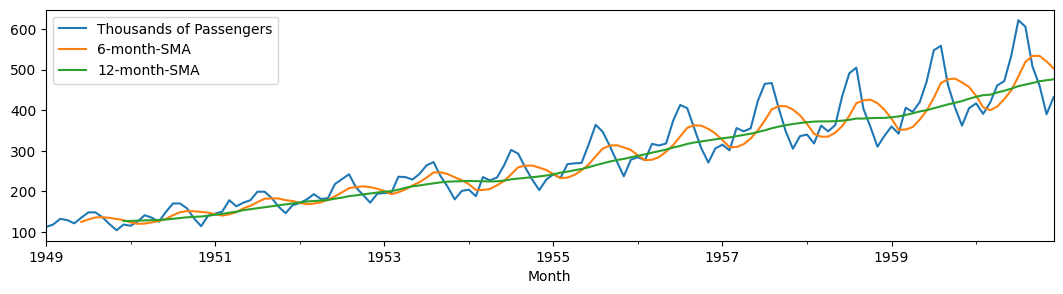

In [55]:
airline.plot(figsize=(13,3));

In [56]:
airline["EWMA-12"] = airline["Thousands of Passengers"].ewm(span=12).mean()

<Axes: xlabel='Month'>

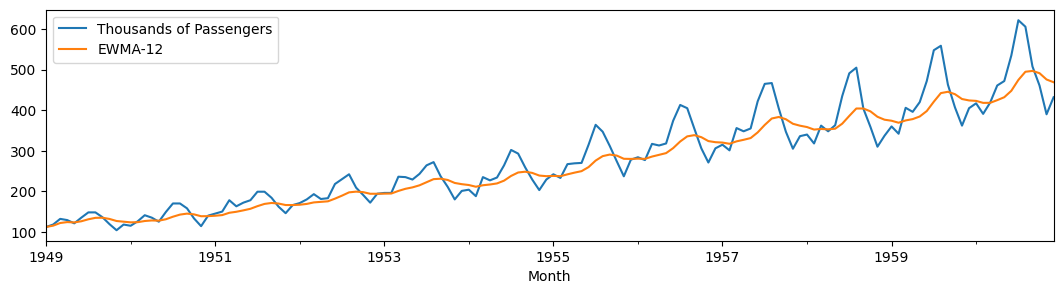

In [57]:
airline[["Thousands of Passengers", "EWMA-12"]].plot(figsize=(13, 3))

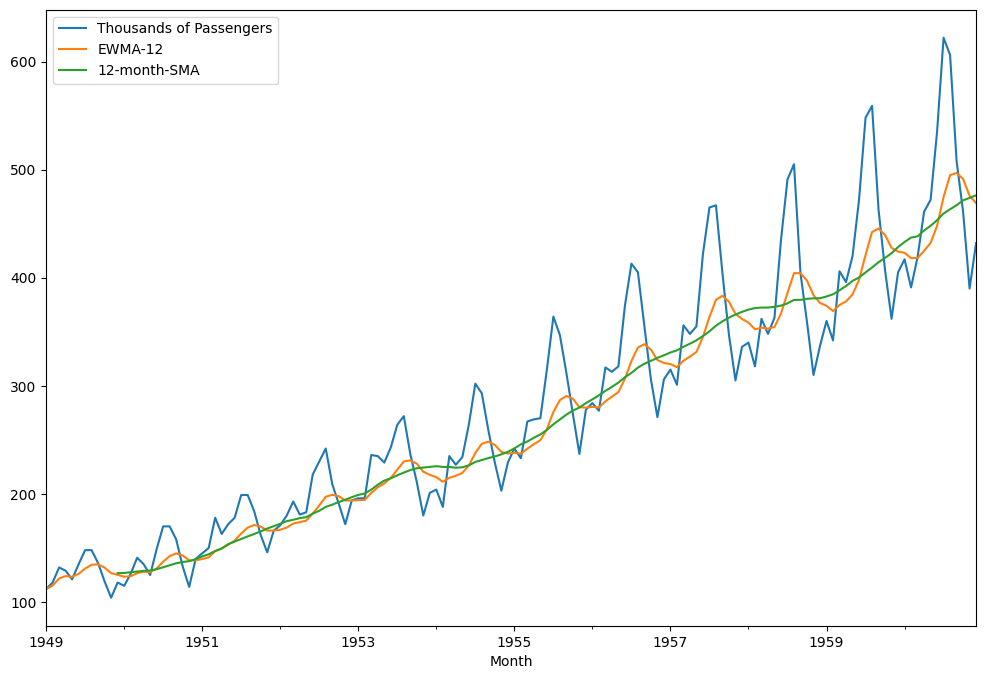

In [60]:
airline[['Thousands of Passengers','EWMA-12','12-month-SMA']].plot(figsize=(12,8)).autoscale(axis='x',tight=True);

### Holt Winters Method

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_csv("Data/airline_passengers.csv", index_col="Month", parse_dates=True)
df

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [5]:
df.dropna(inplace=True)

In [6]:
df

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [7]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [8]:
df.index.freq = "MS"

In [9]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

In [10]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [11]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [12]:
span = 12
alpha = 2 / (span+1)

In [13]:
df["EWMA12"] = df["Thousands of Passengers"].ewm(alpha=alpha, adjust=False).mean()

In [14]:
df.head()

,Thousands of Passengers,EWMA12
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.923077
1949-03-01,132,115.857988
1949-04-01,129,117.879836
1949-05-01,121,118.359861


#### Simple Exponential Method
A variation of the statmodels Holt-Winters function provides Simple Exponential Smoothing. We'll show that it performs the same calculation of the weighted moving average as the pandas <tt>.ewm()</tt> method:<br>

In [15]:
model = SimpleExpSmoothing(df["Thousands of Passengers"])

In [16]:
fitted_model = model.fit(smoothing_level=alpha, optimized=False)

In [17]:
fitted_model.fittedvalues
# Here since optimized equal to False, we got two value is same
# to fix this issue we are going to shift all values one step

Month
1949-01-01    112.000000
1949-02-01    112.000000
1949-03-01    112.923077
1949-04-01    115.857988
1949-05-01    117.879836
                 ...    
1960-08-01    474.698368
1960-09-01    494.898619
1960-10-01    496.914216
1960-11-01    491.388952
1960-12-01    475.790652
Freq: MS, Length: 144, dtype: float64

In [18]:
fitted_model.fittedvalues.shift(-1)

Month
1949-01-01    112.000000
1949-02-01    112.923077
1949-03-01    115.857988
1949-04-01    117.879836
1949-05-01    118.359861
                 ...    
1960-08-01    494.898619
1960-09-01    496.914216
1960-10-01    491.388952
1960-11-01    475.790652
1960-12-01           NaN
Freq: MS, Length: 144, dtype: float64

In [19]:
df["SES12"] = fitted_model.fittedvalues.shift(-1)

In [20]:
df

,Thousands of Passengers,EWMA12,SES12
Month,,,
1949-01-01,112,112.000000,112.000000
1949-02-01,118,112.923077,112.923077
1949-03-01,132,115.857988,115.857988
1949-04-01,129,117.879836,117.879836
1949-05-01,121,118.359861,118.359861
...,...,...,...
1960-08-01,606,494.898619,494.898619
1960-09-01,508,496.914216,496.914216
1960-10-01,461,491.388952,491.388952


___
## Double Exponential Smoothing
Where Simple Exponential Smoothing employs just one smoothing factor $\alpha$ (alpha), Double Exponential Smoothing adds a second smoothing factor $\beta$ (beta) that addresses trends in the data. Like the alpha factor, values for the beta factor fall between zero and one ($0<\beta≤1$). The benefit here is that the model can anticipate future increases or decreases where the level model would only work from recent calculations.

We can also address different types of change (growth/decay) in the trend. If a time series displays a straight-line sloped trend, you would use an <strong>additive</strong> adjustment. If the time series displays an exponential (curved) trend, you would use a <strong>multiplicative</strong> adjustment.

As we move toward forecasting, it's worth noting that both additive and multiplicative adjustments may become exaggerated over time, and require <em>damping</em> that reduces the size of the trend over future periods until it reaches a flat line.

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [22]:
df["DES_add_12"] = ExponentialSmoothing(df["Thousands of Passengers"], trend="add").fit().fittedvalues.shift(-1)

In [23]:
df.columns

Index(['Thousands of Passengers', 'EWMA12', 'SES12', 'DES_add_12'], dtype='object')

<Axes: xlabel='Month'>

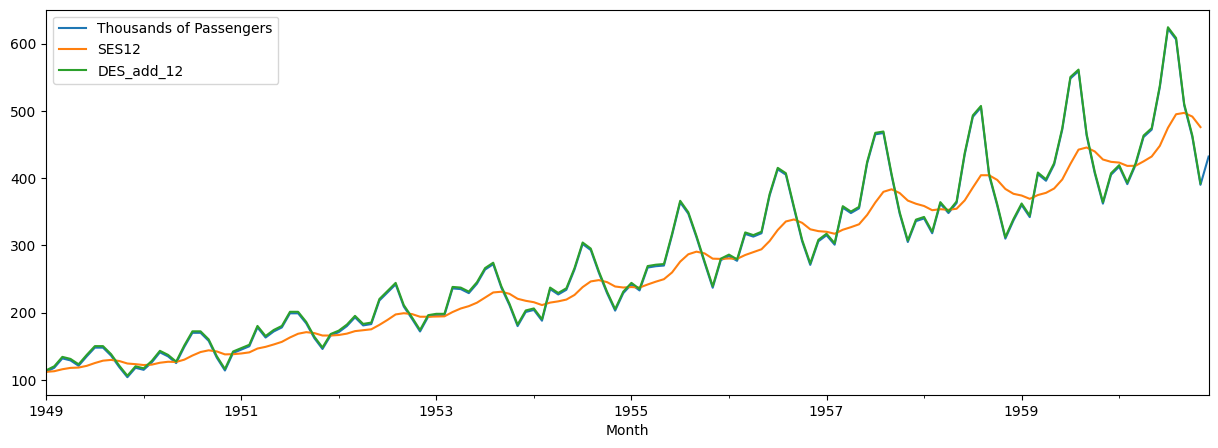

In [24]:
df[['Thousands of Passengers', 'SES12', 'DES_add_12']].plot(figsize=(15, 5))

<Axes: xlabel='Month'>

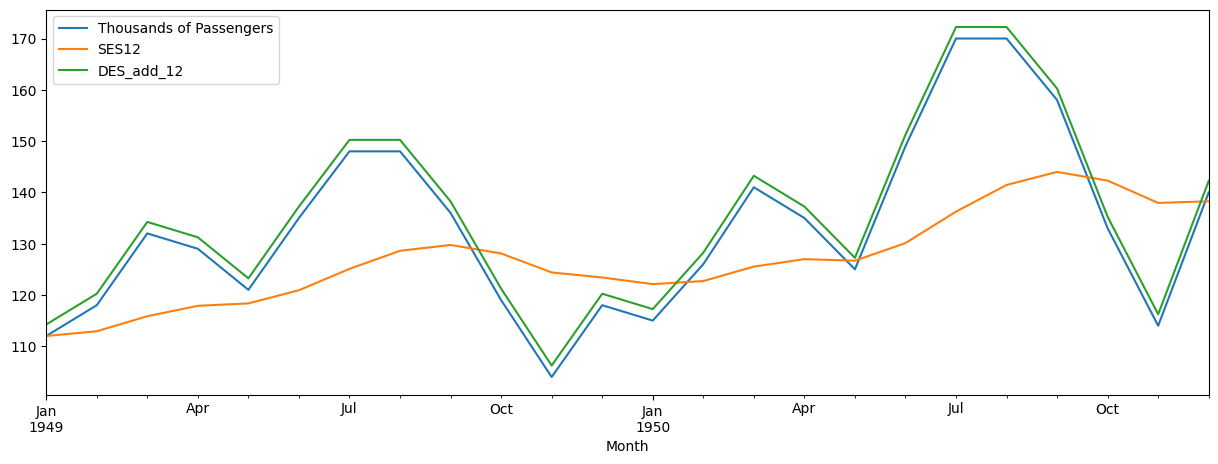

In [25]:
df[['Thousands of Passengers', 'SES12', 'DES_add_12']].iloc[:24].plot(figsize=(15, 5))

<Axes: xlabel='Month'>

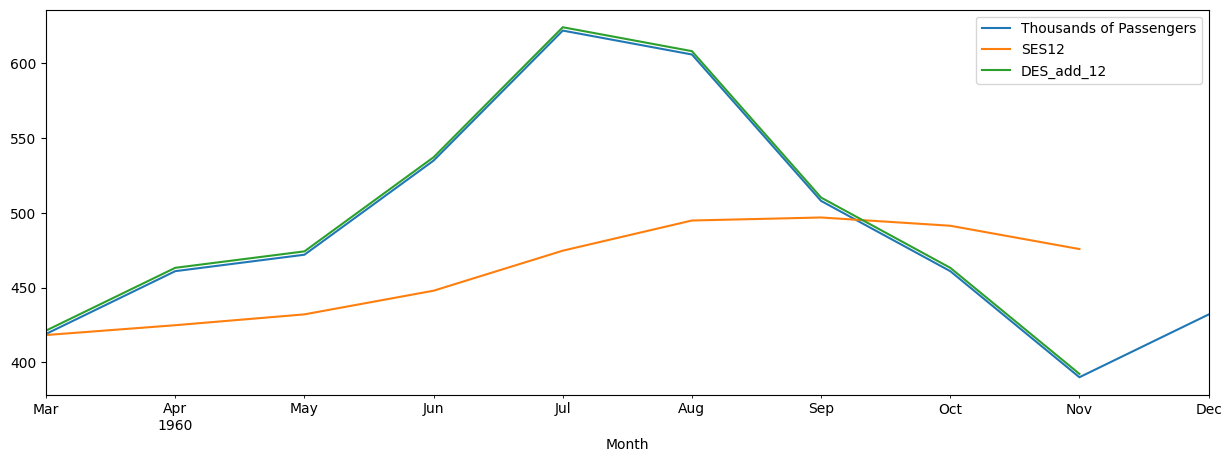

In [26]:
df[['Thousands of Passengers', 'SES12', 'DES_add_12']].iloc[-10:].plot(figsize=(15, 5))

#### Multiplicative

In [27]:
df["DES_multi_12"] = ExponentialSmoothing(df["Thousands of Passengers"], trend="mul").fit().fittedvalues.shift(-1)

In [28]:
df

,Thousands of Passengers,EWMA12,SES12,DES_add_12,DES_multi_12
Month,,,,,
1949-01-01,112,112.000000,112.000000,114.237775,112.049184
1949-02-01,118,112.923077,112.923077,120.237775,118.051819
1949-03-01,132,115.857988,115.857988,134.237774,132.057967
1949-04-01,129,117.879836,117.879836,131.237775,129.056650
1949-05-01,121,118.359861,118.359861,123.237775,121.053137
...,...,...,...,...,...
1960-08-01,606,494.898619,494.898619,608.237775,606.266122
1960-09-01,508,496.914216,496.914216,510.237776,508.223087
1960-10-01,461,491.388952,491.388952,463.237775,461.202446


<Axes: xlabel='Month'>

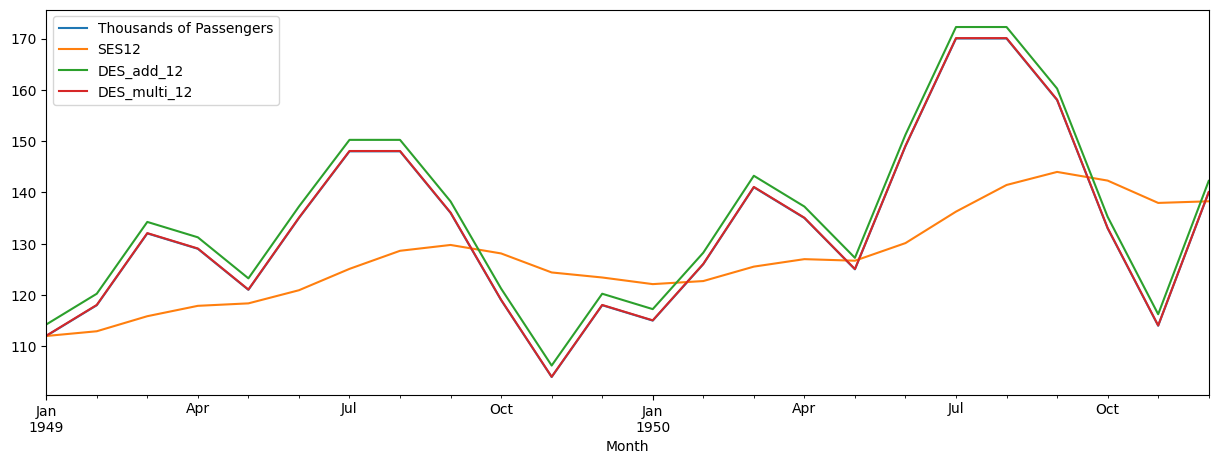

In [29]:
df[['Thousands of Passengers', 'SES12', 'DES_add_12', 'DES_multi_12']].iloc[:24].plot(figsize=(15, 5))

#### How we choose additive or multiplicative?

- if the data graph seems like seasonal so repeating itself and so is growing exponentially over time, we can say it is multiplicative

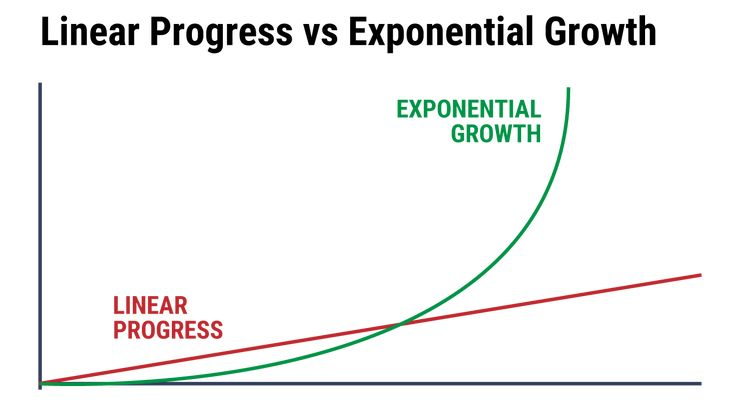

## Triple Exponential Smoothing
Triple Exponential Smoothing, the method most closely associated with Holt-Winters, adds support for both trends and seasonality in the data. 

In [30]:
df["TES_mul_12"] = ExponentialSmoothing(df["Thousands of Passengers"], trend="mul", seasonal="mul", seasonal_periods=12).fit().fittedvalues.shift(-1)

<Axes: xlabel='Month'>

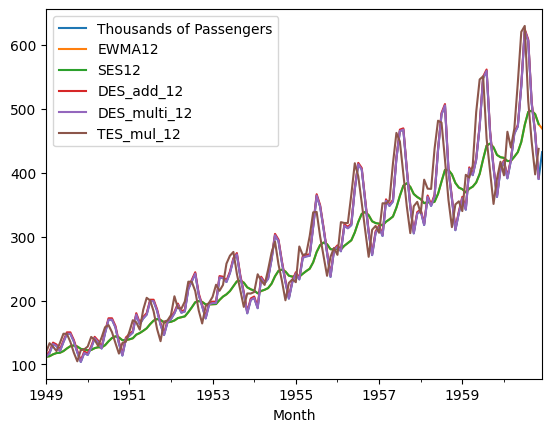

In [32]:
df.plot()

In [33]:
df.columns

Index(['Thousands of Passengers', 'EWMA12', 'SES12', 'DES_add_12',
       'DES_multi_12', 'TES_mul_12'],
      dtype='object')

<Axes: xlabel='Month'>

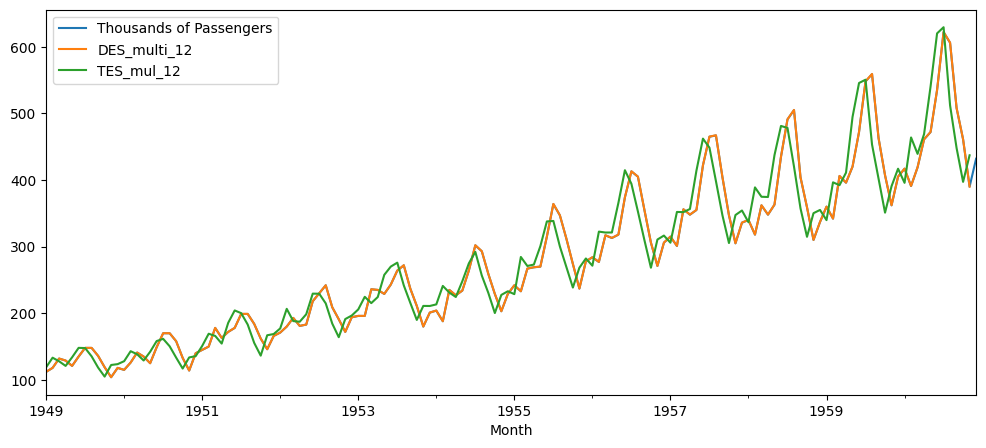

In [34]:
df[['Thousands of Passengers', 'DES_multi_12', 'TES_mul_12']].plot(figsize=(12, 5))

<Axes: xlabel='Month'>

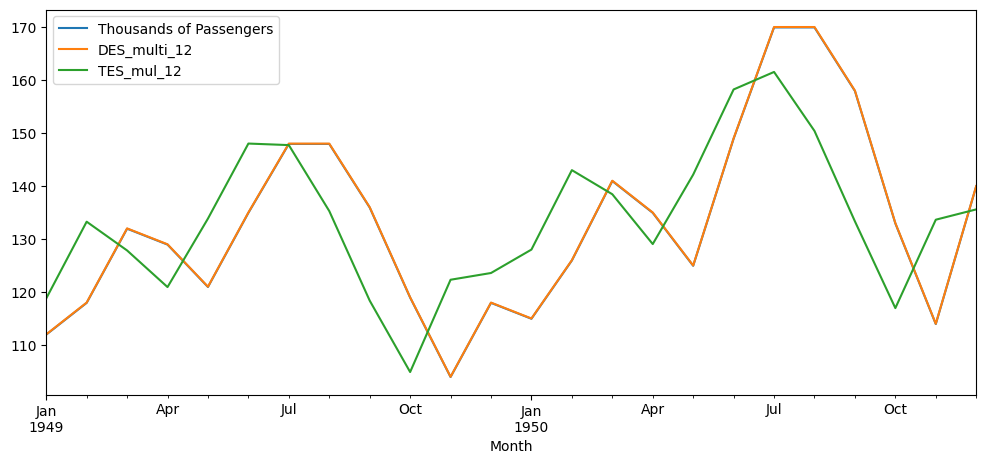

In [35]:
df[['Thousands of Passengers', 'DES_multi_12', 'TES_mul_12']].iloc[:24].plot(figsize=(12, 5))